In [ ]:
# CELL 1: SETUP AND IMPORTS
!pip install --quiet faiss-gpu rapidfuzz xgboost cupy-cuda12x psutil cudf-cu12 dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com

import os, gc, re, csv, zipfile, sqlite3, urllib.request, psutil
import numpy as np, pandas as pd, xgboost as xgb
import cupy as cp, cupyx.scipy.sparse as cpx_sparse
import faiss
from rapidfuzz import fuzz
from rapidfuzz.distance import JaroWinkler
from sklearn.feature_extraction.text import HashingVectorizer

try:
    import cudf
    USE_CUDF = True
    print("cuDF loaded successfully! GPU will be used for ETL.")
except ImportError:
    USE_CUDF = False
    print("cuDF not found. Falling back to CPU Pandas.")

for d in ["dataset/train", "dataset/test", "output", "utils"]: os.makedirs(d, exist_ok=True)
print("FAISS Environment setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.0 MB/s eta 0:00:00
cuDF loaded successfully! GPU will be used for ETL.
FAISS Environment setup complete.


In [ ]:
# CELL 2: DOWNLOAD DATA
DATA_URL = "https://cdn.unstop.com/files/6ab10eb3b23ba_student_resource.zip"
if not os.path.exists("dataset/train/train_source1.tsv"):
    print("Downloading 30M row dataset...")
    urllib.request.urlretrieve(DATA_URL, "dataset.zip")
    with zipfile.ZipFile("dataset.zip", "r") as z: z.extractall("temp_data")
    import shutil
    for root, _, files in os.walk("temp_data"):
        for f in files:
            if f.endswith(".tsv"):
                folder = "train" if "train" in root.lower() or "train" in f.lower() else "test"
                shutil.copy(os.path.join(root, f), os.path.join(f"dataset/{folder}", f))
    shutil.rmtree("temp_data"); os.remove("dataset.zip")
    print("Data downloaded and extracted.")
else:
    print("Data already exists. Skipping download.")

Data downloaded and extracted.


In [ ]:
# CELL 3: BUILD OUT-OF-CORE DATABASE
DB_PATH = "pool_data.db"

def clean_text(text):
    if not isinstance(text, str): return ""
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", text.lower())).strip()

if not os.path.exists(DB_PATH):
    print("Building Out-of-Core SQLite Database for Pool Records...")
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    c.execute("PRAGMA synchronous = OFF"); c.execute("PRAGMA journal_mode = MEMORY")
    c.execute("CREATE TABLE pool (entity_id TEXT PRIMARY KEY, country TEXT, name TEXT, addr TEXT, combined TEXT, nums TEXT)")

    for file in ["dataset/train/train_source2.tsv", "dataset/train/train_source3.tsv",
                 "dataset/test/test_source2.tsv", "dataset/test/test_source3.tsv"]:
        print(f"Streaming {file} into DB...")
        for chunk_pd in pd.read_csv(file, sep="\t", dtype=str, chunksize=500000):
            if USE_CUDF:
                gdf = cudf.from_pandas(chunk_pd)
                gdf["country"] = gdf["country"].fillna("UNKNOWN").str.strip().str.upper()
                gdf["name"] = gdf["business_name"].fillna("").str.lower().str.replace(r"[^\w\s]", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
                gdf["addr"] = gdf["business_address"].fillna("").str.lower().str.replace(r"[^\w\s]", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
                gdf["combined"] = gdf["name"] + " " + gdf["addr"]
                chunk_pd = gdf.to_pandas()
                del gdf
            else:
                chunk_pd["country"] = chunk_pd["country"].fillna("UNKNOWN").str.strip().str.upper()
                chunk_pd["name"] = chunk_pd["business_name"].apply(clean_text)
                chunk_pd["addr"] = chunk_pd["business_address"].apply(clean_text)
                chunk_pd["combined"] = chunk_pd["name"] + " " + chunk_pd["addr"]

            chunk_pd["nums"] = chunk_pd["addr"].apply(lambda x: ",".join(re.findall(r"\b\d+\b", x)))
            c.executemany("INSERT OR IGNORE INTO pool VALUES (?,?,?,?,?,?)", chunk_pd[["entity_id", "country", "name", "addr", "combined", "nums"]].values.tolist())

    c.execute("CREATE INDEX idx_country ON pool(country)")
    conn.commit(); conn.close()
    print("Database built successfully!")
else:
    print("Database already exists. Skipping construction.")

Building Out-of-Core SQLite Database for Pool Records...
Streaming dataset/train/train_source2.tsv into DB...
Streaming dataset/train/train_source3.tsv into DB...
Streaming dataset/test/test_source2.tsv into DB...
Streaming dataset/test/test_source3.tsv into DB...
Database built successfully!


In [ ]:
# CELL 4: FAISS VECTORIZATION & HELPER FUNCTIONS
VECTOR_DIM = 256  # Squashes 32k dimensions down to 256 for FAISS RAM efficiency

# 1. Base Sparse Hash
vectorizer = HashingVectorizer(analyzer="char_wb", ngram_range=(3,3), n_features=2**15, dtype=np.float32)

# 2. Random Projection Matrix for Locality Sensitive Hashing (LSH)
np.random.seed(42)
R_PROJECTION = np.random.randn(2**15, VECTOR_DIM).astype(np.float32) / np.sqrt(VECTOR_DIM)

def text_to_dense_l2(texts):
    """Converts strings to sparse matrix, projects to dense 256d, and L2 normalizes for FAISS Cosine"""
    sparse_mat = vectorizer.transform(texts)
    dense_mat = np.ascontiguousarray(sparse_mat.dot(R_PROJECTION).astype(np.float32))
    faiss.normalize_L2(dense_mat) # In-place Normalization
    return dense_mat

def build_country_faiss_index(country, conn):
    """Streams a specific country from SQLite directly into a GPU FAISS Index"""
    c = conn.cursor()
    c.execute("SELECT COUNT(*) FROM pool WHERE country=?", (country,))
    total = c.fetchone()[0]

    # Use Inner Product (which equals Cosine Similarity because we L2 normalized)
    cpu_index = faiss.IndexFlatIP(VECTOR_DIM)
    res = faiss.StandardGpuResources()
    gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)

    global_ids = []
    chunk_size = 200000 # Process 200k at a time

    print(f"Building FAISS Index for {country} ({total:,} records)...")
    for offset in range(0, total, chunk_size):
        c.execute("SELECT entity_id, combined FROM pool WHERE country=? LIMIT ? OFFSET ?", (country, chunk_size, offset))
        data = c.fetchall()
        if not data: break

        global_ids.extend([row[0] for row in data])
        dense_batch = text_to_dense_l2([row[1] for row in data])
        gpu_index.add(dense_batch)

    return gpu_index, global_ids

def get_top_k_candidates_faiss(s1_chunk, index, global_ids, top_k=10):
    """Queries the GPU FAISS index in milliseconds"""
    n_s1 = len(s1_chunk)
    final_ids = np.empty((n_s1, top_k), dtype=object)
    if n_s1 == 0: return final_ids

    dense_query = text_to_dense_l2(s1_chunk["combined"].tolist())
    distances, indices = index.search(dense_query, top_k)

    for i in range(n_s1):
        for j in range(top_k):
            idx = indices[i, j]
            # Lowered cutoff to 0.25 because LSH projection introduces slight distance noise
            if idx != -1 and distances[i, j] >= 0.25:
                final_ids[i, j] = global_ids[idx]
            else:
                final_ids[i, j] = None
    return final_ids

def bulk_fetch_candidates(c, cand_ids):
    pool_dict = {}
    cand_list = list(set(cand_ids))
    for i in range(0, len(cand_list), 900):
        chunk = cand_list[i:i+900]
        c.execute(f"SELECT entity_id, name, addr, nums FROM pool WHERE entity_id IN ({','.join(['?']*len(chunk))})", chunk)
        for row in c.fetchall(): pool_dict[row[0]] = (row[1], row[2], row[3])
    return pool_dict

def extract_features(n1, a1, num1_str, n2, a2, num2_str):
    n1, a1, n2, a2 = n1 or "", a1 or "", n2 or "", a2 or ""
    nums1, nums2 = set(num1_str.split(",")) if num1_str else set(), set(num2_str.split(",")) if num2_str else set()
    nums1.discard(""); nums2.discard("")
    d_jac = len(nums1 & nums2) / len(nums1 | nums2) if nums1 and nums2 else 0.0
    d_match = 1.0 if nums1 and nums2 and (nums1 & nums2) else (0.5 if not nums1 or not nums2 else 0.0)
    return [fuzz.ratio(n1, n2)/100.0, fuzz.token_sort_ratio(n1, n2)/100.0, JaroWinkler.similarity(n1, n2), fuzz.ratio(a1, a2)/100.0, d_jac, d_match]

print("FAISS engines loaded successfully.")

FAISS engines loaded successfully.


In [ ]:
# CELL 4: FAISS VECTORIZATION & HELPER FUNCTIONS
VECTOR_DIM = 64  # FIXED: 64 dimensions * 10M records = ~2.5 GB VRAM!

# 1. Base Sparse Hash
vectorizer = HashingVectorizer(analyzer="char_wb", ngram_range=(3,3), n_features=2**15, dtype=np.float32)

# 2. Random Projection Matrix for Locality Sensitive Hashing (LSH)
np.random.seed(42)
R_PROJECTION = np.random.randn(2**15, VECTOR_DIM).astype(np.float32) / np.sqrt(VECTOR_DIM)

def text_to_dense_l2(texts):
    """Converts strings to sparse matrix, projects to dense 64d, and L2 normalizes for FAISS Cosine"""
    sparse_mat = vectorizer.transform(texts)
    dense_mat = np.ascontiguousarray(sparse_mat.dot(R_PROJECTION).astype(np.float32))
    faiss.normalize_L2(dense_mat) # In-place Normalization
    return dense_mat

def build_country_faiss_index(country, conn):
    """Streams a specific country from SQLite directly into a GPU FAISS Index"""
    c = conn.cursor()
    c.execute("SELECT COUNT(*) FROM pool WHERE country=?", (country,))
    total = c.fetchone()[0]

    # Use Inner Product (which equals Cosine Similarity because we L2 normalized)
    cpu_index = faiss.IndexFlatIP(VECTOR_DIM)
    res = faiss.StandardGpuResources()

    # Optional safety: prevent FAISS from pre-allocating massive temp memory chunks
    res.noTempMemory()
    gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)

    global_ids = []
    chunk_size = 200000 # Process 200k at a time

    print(f"Building FAISS Index for {country} ({total:,} records)...")
    for offset in range(0, total, chunk_size):
        c.execute("SELECT entity_id, combined FROM pool WHERE country=? LIMIT ? OFFSET ?", (country, chunk_size, offset))
        data = c.fetchall()
        if not data: break

        global_ids.extend([row[0] for row in data])
        dense_batch = text_to_dense_l2([row[1] for row in data])
        gpu_index.add(dense_batch)

    return gpu_index, global_ids

def get_top_k_candidates_faiss(s1_chunk, index, global_ids, top_k=15):
    """Queries the GPU FAISS index in milliseconds (Increased top_k to 15 for safety)"""
    n_s1 = len(s1_chunk)
    final_ids = np.empty((n_s1, top_k), dtype=object)
    if n_s1 == 0: return final_ids

    dense_query = text_to_dense_l2(s1_chunk["combined"].tolist())
    distances, indices = index.search(dense_query, top_k)

    for i in range(n_s1):
        for j in range(top_k):
            idx = indices[i, j]
            if idx != -1 and distances[i, j] >= 0.25:
                final_ids[i, j] = global_ids[idx]
            else:
                final_ids[i, j] = None
    return final_ids

def bulk_fetch_candidates(c, cand_ids):
    pool_dict = {}
    cand_list = list(set(cand_ids))
    for i in range(0, len(cand_list), 900):
        chunk = cand_list[i:i+900]
        c.execute(f"SELECT entity_id, name, addr, nums FROM pool WHERE entity_id IN ({','.join(['?']*len(chunk))})", chunk)
        for row in c.fetchall(): pool_dict[row[0]] = (row[1], row[2], row[3])
    return pool_dict

def extract_features(n1, a1, num1_str, n2, a2, num2_str):
    n1, a1, n2, a2 = n1 or "", a1 or "", n2 or "", a2 or ""
    nums1, nums2 = set(num1_str.split(",")) if num1_str else set(), set(num2_str.split(",")) if num2_str else set()
    nums1.discard(""); nums2.discard("")
    d_jac = len(nums1 & nums2) / len(nums1 | nums2) if nums1 and nums2 else 0.0
    d_match = 1.0 if nums1 and nums2 and (nums1 & nums2) else (0.5 if not nums1 or not nums2 else 0.0)
    return [fuzz.ratio(n1, n2)/100.0, fuzz.token_sort_ratio(n1, n2)/100.0, JaroWinkler.similarity(n1, n2), fuzz.ratio(a1, a2)/100.0, d_jac, d_match]

print("FAISS engines loaded successfully.")

FAISS engines loaded successfully.


In [ ]:
# CELL 5: TRAIN XGBOOST MODEL (VIA FAISS)
print("Loading Training Split...")
s1_all = pd.read_csv("dataset/train/train_source1.tsv", sep="\t", dtype=str, nrows=50000)
s1_all["country"] = s1_all["country"].fillna("UNKNOWN").str.strip().str.upper()
s1_all["name"] = s1_all["business_name"].apply(clean_text)
s1_all["addr"] = s1_all["business_address"].apply(clean_text)
s1_all["combined"] = s1_all["name"] + " " + s1_all["addr"]
s1_all["nums"] = s1_all["addr"].apply(lambda x: ",".join(re.findall(r"\b\d+\b", x)))

s1_train = s1_all.iloc[:40000].reset_index(drop=True)
s1_val = s1_all.iloc[40000:50000].reset_index(drop=True)

gt_df = pd.read_csv("dataset/train/train_ground_truth.tsv", sep="\t", dtype=str)
gt_map = {row["source1_entity_id"]: set(str(row["matched_entity_ids"]).split(",")) if pd.notna(row["matched_entity_ids"]) else set() for _, row in gt_df.iterrows()}

conn = sqlite3.connect(DB_PATH)
X_train, y_train = [], []

for country in s1_train["country"].unique():
    s1_c = s1_train[s1_train["country"] == country].reset_index(drop=True)

    # 1. Build FAISS for this country
    country_index, global_ids = build_country_faiss_index(country, conn)

    # 2. Lightning fast query
    top_cands = get_top_k_candidates_faiss(s1_c, country_index, global_ids)

    c = conn.cursor()
    all_cands = set()
    for i, s1_id in enumerate(s1_c["entity_id"]):
        all_cands.update([cand for cand in top_cands[i] if cand is not None])
        all_cands.update(gt_map.get(s1_id, set()))
    pool_data_dict = bulk_fetch_candidates(c, list(all_cands))

    for i, s1_id in enumerate(s1_c["entity_id"]):
        cands = [cand for cand in top_cands[i] if cand is not None]
        true_m = gt_map.get(s1_id, set())
        for cand_id in set(cands) | true_m:
            if cand_id in pool_data_dict:
                n2, a2, num2 = pool_data_dict[cand_id]
                X_train.append(extract_features(s1_c.at[i, "name"], s1_c.at[i, "addr"], s1_c.at[i, "nums"], n2, a2, num2))
                y_train.append(1 if cand_id in true_m else 0)

    # 3. Free Memory!
    del country_index, global_ids
    gc.collect()

print("Training XGBoost...")
model = xgb.XGBClassifier(n_estimators=450, learning_rate=0.05, max_depth=6, tree_method="hist", device="cuda", eval_metric="logloss", random_state=42)
model.fit(np.array(X_train), np.array(y_train))
print("Model training complete.")

Loading Training Split...
Building FAISS Index for US (10,003,904 records)...
Building FAISS Index for INDIA (8,850,911 records)...
Training XGBoost...
Model training complete.


In [ ]:
# CELL 6: VALIDATE ON HOLDOUT SET
print("Validating on Holdout Set...")
val_preds = {}
for country in s1_val["country"].unique():
    s1_c = s1_val[s1_val["country"] == country].reset_index(drop=True)

    country_index, global_ids = build_country_faiss_index(country, conn)
    top_cands = get_top_k_candidates_faiss(s1_c, country_index, global_ids)

    c = conn.cursor()
    all_cands = set()
    for i in range(len(s1_c)): all_cands.update([cand for cand in top_cands[i] if cand is not None])
    pool_data_dict = bulk_fetch_candidates(c, list(all_cands))

    for i, s1_id in enumerate(s1_c["entity_id"]):
        cands = [cand for cand in top_cands[i] if cand is not None]
        val_preds[s1_id] = set()
        if not cands: continue

        X_test = []
        valid_cands = []
        for cand_id in cands:
            if cand_id in pool_data_dict:
                n2, a2, num2 = pool_data_dict[cand_id]
                X_test.append(extract_features(s1_c.at[i, "name"], s1_c.at[i, "addr"], s1_c.at[i, "nums"], n2, a2, num2))
                valid_cands.append(cand_id)

        if X_test:
            probs = model.predict_proba(np.array(X_test))[:, 1]
            for idx, p in enumerate(probs):
                if p >= 0.75: val_preds[s1_id].add(valid_cands[idx])

    del country_index, global_ids
    gc.collect()

f05_scores, precisions, recalls = [], [], []
for s1_id in s1_val["entity_id"]:
    true_set = gt_map.get(s1_id, set())
    pred_set = val_preds.get(s1_id, set())

    if not true_set:
        if not pred_set: f05_scores.append(1.0); precisions.append(1.0); recalls.append(1.0)
        else: f05_scores.append(0.0); precisions.append(0.0); recalls.append(1.0)
        continue
    if not pred_set:
        f05_scores.append(0.0); precisions.append(1.0); recalls.append(0.0)
        continue

    tp, fp, fn = len(true_set & pred_set), len(pred_set - true_set), len(true_set - pred_set)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    denom = (0.25 * prec) + rec
    f05_scores.append((1.25 * prec * rec) / denom if denom > 0 else 0.0)
    precisions.append(prec); recalls.append(rec)

print(f"\nValidation Size : {len(s1_val):,} entities")
print(f"Precision       : {np.mean(precisions):.4f}")
print(f"Recall          : {np.mean(recalls):.4f}")
print(f"F_0.5 Score     : {np.mean(f05_scores):.4f}")

Validating on Holdout Set...
Building FAISS Index for INDIA (8,850,911 records)...


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [12:27:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Building FAISS Index for US (10,003,904 records)...

Validation Size : 10,000 entities
Precision       : 0.9644
Recall          : 0.7157
F_0.5 Score     : 0.8344


In [ ]:
# CELL 7: FINAL TEST INFERENCE
print("=== FINAL TEST INFERENCE ===")
f_cand = open("output/candidate_pairs.tsv", "w", newline="")
f_match = open("output/matching_results.tsv", "w", newline="")
cw, mw = csv.writer(f_cand, delimiter="\t"), csv.writer(f_match, delimiter="\t")
cw.writerow(["source1_entity_id", "candidate_entity_ids"])
mw.writerow(["source1_entity_id", "matched_entity_ids"])

# Load full S1 Test set into memory to group by country efficiently
s1_test = pd.read_csv("dataset/test/test_source1.tsv", sep="\t", dtype=str)
s1_test["country"] = s1_test["country"].fillna("UNKNOWN").str.strip().str.upper()
s1_test["name"] = s1_test["business_name"].apply(clean_text)
s1_test["addr"] = s1_test["business_address"].apply(clean_text)
s1_test["combined"] = s1_test["name"] + " " + s1_test["addr"]
s1_test["nums"] = s1_test["addr"].apply(lambda x: ",".join(re.findall(r"\b\d+\b", x)))

for country in s1_test["country"].unique():
    s1_c = s1_test[s1_test["country"] == country].reset_index(drop=True)

    country_index, global_ids = build_country_faiss_index(country, conn)
    c = conn.cursor()

    print(f"Running inference for {country}...")
    for chunk_start in range(0, len(s1_c), 5000):
        chunk = s1_c.iloc[chunk_start:chunk_start+5000].reset_index(drop=True)
        top_cands = get_top_k_candidates_faiss(chunk, country_index, global_ids)

        all_cands = set()
        for i in range(len(chunk)): all_cands.update([cand for cand in top_cands[i] if cand is not None])
        pool_data_dict = bulk_fetch_candidates(c, list(all_cands))

        for i, s1_id in enumerate(chunk["entity_id"]):
            cands = [cand for cand in top_cands[i] if cand is not None]
            cw.writerow([s1_id, ",".join(cands)])

            if not cands:
                mw.writerow([s1_id, ""])
                continue

            X_test, valid_cands = [], []
            for cand_id in cands:
                if cand_id in pool_data_dict:
                    n2, a2, num2 = pool_data_dict[cand_id]
                    X_test.append(extract_features(chunk.at[i, "name"], chunk.at[i, "addr"], chunk.at[i, "nums"], n2, a2, num2))
                    valid_cands.append(cand_id)

            if X_test:
                probs = model.predict_proba(np.array(X_test))[:, 1]
                matches = [valid_cands[idx] for idx, p in enumerate(probs) if p >= 0.75]
                mw.writerow([s1_id, ",".join(matches)])
            else:
                mw.writerow([s1_id, ""])

    del country_index, global_ids
    gc.collect()

f_cand.close(); f_match.close(); conn.close()
print("✅ Output streamed to output/ directory.")

=== FINAL TEST INFERENCE ===
Building FAISS Index for US (10,003,904 records)...
Running inference for US...
Building FAISS Index for FRANCE (1,434,993 records)...
Running inference for FRANCE...
Building FAISS Index for INDIA (8,850,911 records)...
Running inference for INDIA...
✅ Output streamed to output/ directory.


In [ ]:
# SAVE THE TRAINED XGBOOST MODEL
model_path = "output/xgb_entity_model.json"
model.save_model(model_path)
print(f"✅ Model successfully saved to {model_path}")

# Optional: Automatically trigger the download to your computer
from google.colab import files
files.download(model_path)

✅ Model successfully saved to output/xgb_entity_model.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FAIL
- Invalid match ID S3-838537939 in S1-910004085
- Invalid match ID S3-153917787 in S1-158003567
- Invalid match ID S2-753268634 in S1-686724393
- Invalid match ID S2-436175202 in S1-616686159
- Invalid match ID S3-842273953 in S1-149472874
- Invalid match ID S2-808407699 in S1-67005936
- Invalid match ID S3-803846647 in S1-871733171
- Invalid match ID S3-567152076 in S1-643352695
- Invalid match ID S2-679108450 in S1-733416826
- Invalid match ID S2-236599825 in S1-188463826
🎉 Success! Final_Submission_Outputs.zip created.

Generating Documentation Graphs...


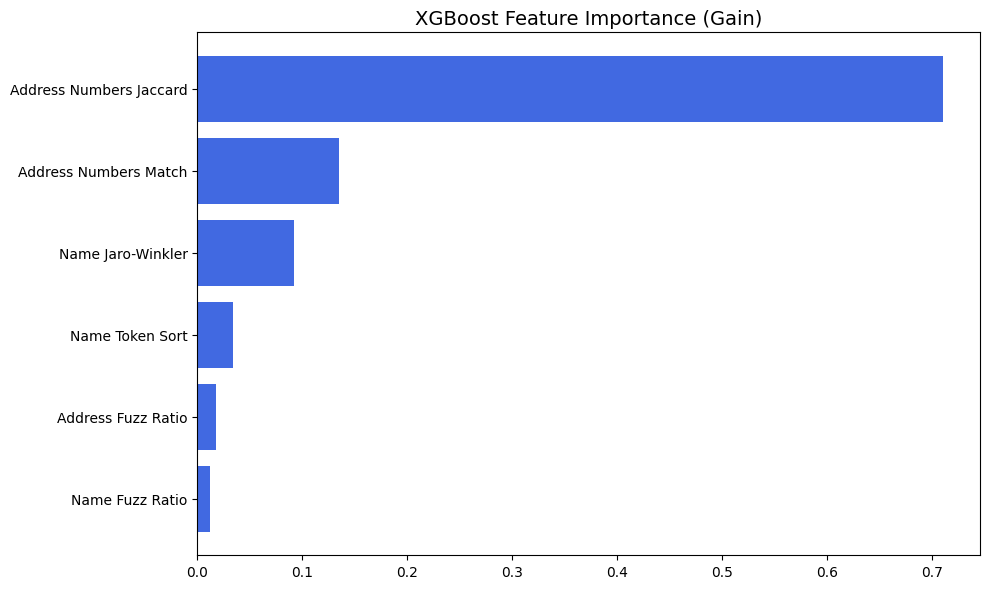

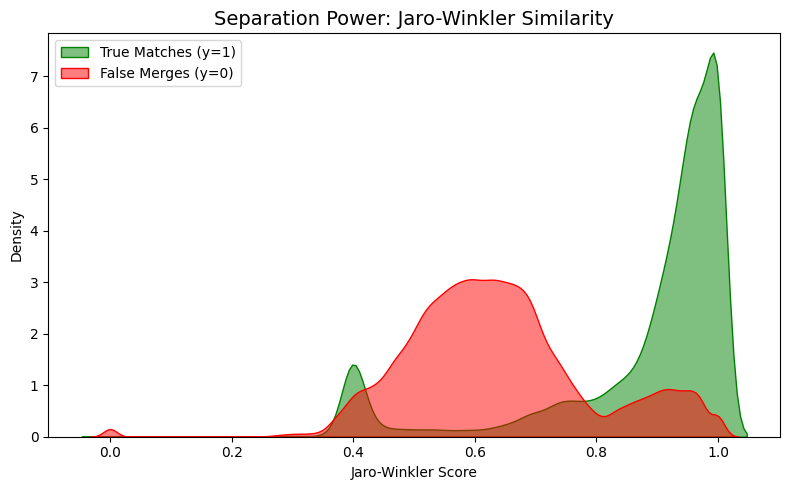

In [ ]:
# CELL 8: VALIDATOR, ZIPPING, AND GRAPH GENERATION
import sys, os, pandas as pd, argparse
import matplotlib.pyplot as plt, seaborn as sns

# 1. RUN VALIDATOR
validator_code = """
import sys, os, pandas as pd, argparse
def validate(matching_file, candidate_file, test_dir):
    issues = []
    s1_path, s2_path, s3_path = os.path.join(test_dir, "test_source1.tsv"), os.path.join(test_dir, "test_source2.tsv"), os.path.join(test_dir, "test_source3.tsv")
    valid_s1 = set(pd.read_csv(s1_path, sep="\\t")["entity_id"].dropna().astype(str))
    valid_pool = set(pd.read_csv(s2_path, sep="\\t")["entity_id"].dropna().astype(str)).union(set(pd.read_csv(s3_path, sep="\\t")["entity_id"].dropna().astype(str)))
    df_match = pd.read_csv(matching_file, sep="\\t", dtype=str, keep_default_na=False)
    df_cand = pd.read_csv(candidate_file, sep="\\t", dtype=str, keep_default_na=False)
    if list(df_match.columns) != ["source1_entity_id", "matched_entity_ids"]: issues.append("Bad Match Columns")
    if list(df_cand.columns) != ["source1_entity_id", "candidate_entity_ids"]: issues.append("Bad Cand Columns")
    if len(df_match["source1_entity_id"]) != len(set(df_match["source1_entity_id"])): issues.append("Match Duplicates")
    if set(df_match["source1_entity_id"]) != valid_s1: issues.append("Missing/Extra Source 1 IDs")
    cand_map = dict(zip(df_cand["source1_entity_id"], df_cand["candidate_entity_ids"]))
    for _, row in df_match.iterrows():
        s1 = row["source1_entity_id"]
        matches = [m.strip() for m in row["matched_entity_ids"].split(",")] if row["matched_entity_ids"] else []
        cands = [c.strip() for c in cand_map.get(s1, "").split(",")] if cand_map.get(s1, "") else []
        if len(matches) != len(set(matches)): issues.append(f"Dup matches in {s1}")
        for m in matches:
            if m not in valid_pool: issues.append(f"Invalid match ID {m} in {s1}")
            if m not in cands: issues.append(f"Match {m} not in candidates for {s1}")
    if issues:
        print("FAIL"); [print(f"- {i}") for i in issues[:10]]; sys.exit(1)
    print("PASS: Safe to submit!"); sys.exit(0)
if __name__ == "__main__":
    parser = argparse.ArgumentParser(); parser.add_argument("--matching", required=True); parser.add_argument("--candidate", required=True); parser.add_argument("--test-dir", required=True)
    args = parser.parse_args(); validate(args.matching, args.candidate, args.test_dir)
"""
with open("utils/validate_submission.py", "w") as f: f.write(validator_code)
!python3 utils/validate_submission.py --matching output/matching_results.tsv --candidate output/candidate_pairs.tsv --test-dir dataset/test

# 2. ZIP OUTPUTS
zip_name = "Final_Submission_Outputs.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("output/matching_results.tsv", "output/matching_results.tsv")
    zipf.write("output/candidate_pairs.tsv", "output/candidate_pairs.tsv")
print(f"🎉 Success! {zip_name} created.")

# 3. GENERATE METHODOLOGY GRAPHS
print("\nGenerating Documentation Graphs...")
feature_names = ["Name Fuzz Ratio", "Name Token Sort", "Name Jaro-Winkler", "Address Fuzz Ratio", "Address Numbers Jaccard", "Address Numbers Match"]
plt.figure(figsize=(10, 6))
importance = model.feature_importances_
indices = np.argsort(importance)
plt.barh(range(len(indices)), importance[indices], color='royalblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("XGBoost Feature Importance (Gain)", fontsize=14); plt.tight_layout()
plt.savefig("output/feature_importance.png", dpi=300); plt.show()

X_train_np, y_train_np = np.array(X_train), np.array(y_train)
plt.figure(figsize=(8, 5))
sns.kdeplot(X_train_np[y_train_np == 1, 2], label="True Matches (y=1)", fill=True, color="green", alpha=0.5)
sns.kdeplot(X_train_np[y_train_np == 0, 2], label="False Merges (y=0)", fill=True, color="red", alpha=0.5)
plt.title("Separation Power: Jaro-Winkler Similarity", fontsize=14)
plt.xlabel("Jaro-Winkler Score"); plt.ylabel("Density"); plt.legend(); plt.tight_layout()
plt.savefig("output/jaro_winkler_separation.png", dpi=300); plt.show()